# EDA


## Number of particles per event

In [1]:
#Import custom classes and libraries
from src.Data.data_loading import ParquetFeatureDataset

import yaml
import numpy as np
import fastjet
from tqdm import tqdm
import torch
import lightning as L
import matplotlib.pyplot as plt


#Open config file
with open("Configs/config.yaml") as f:
    config = yaml.safe_load(f)

#Extract config info
dirs_train = config["data"]["train_path"]
dirs_val = config["data"]["val_path"]
dirs_test = config["data"]["test_path"]

features_cols = config["data"]["features"]

input_dim = config["model"]["input_dim"]
hidden_dim = config["model"]["hidden_dim"]
latent_dim = config["model"]["latent_dim"]
codebook_size = config["model"]["codebook_size"]

lr = config["training"]["lr"]
max_epochs = config["training"]["max_epochs"]


#Initialization of itarable dataset (train dataset) containing the constituents' features (eta, phi, pT) (preprocessed)
#In particular I am currently using the first 2 parquet files
dataset_preprocessed = ParquetFeatureDataset(
    parquet_dirs=dirs_train,
    features=features_cols,
    preprocessing=True,
    max_particles=256,
    #batch_size=32
)

#Initialization of itarable dataset (train dataset) containing the constituents' features (eta, phi, pT) (not preprocessed)
#In particular I am currently using the first 2 parquet files
dataset_not_preprocessed = ParquetFeatureDataset(
    parquet_dirs=dirs_train,
    features=features_cols,
    preprocessing=False,
    max_particles=256
    #batch_size=32
)

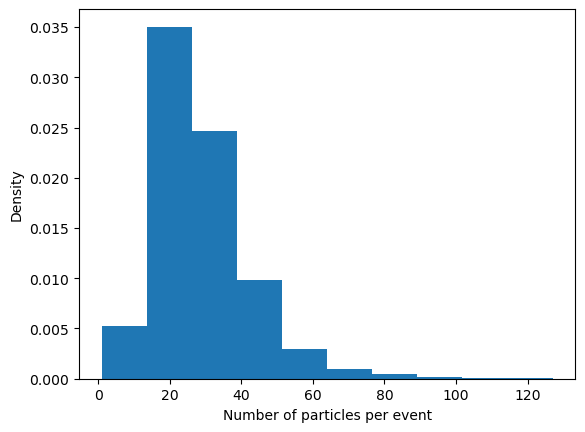

In [2]:
valide_part = []

#Compute the number of particles for each event
for batch, mask in dataset_preprocessed:
    for event in mask:
        valide_part.append(event.sum())

plt.hist(valide_part, density=True)
plt.xlabel("Number of particles per event")
plt.ylabel("Density")
plt.show()

## Features

In [ ]:
#Return the particles' features of all the events
def extract_features(data):
    
    eta_list = []
    phi_list = []
    pT_list = []

    for batch, mask in data:
        for i in range(batch.shape[0]):
            valid = batch[i][mask[i]]
            for eta, phi, pT in valid:
                eta_list.append(eta)
                phi_list.append(phi)
                pT_list.append(pT)
    
    return eta_list, phi_list, pT_list

In [4]:
eta, phi, pT = extract_features(dataset_not_preprocessed)

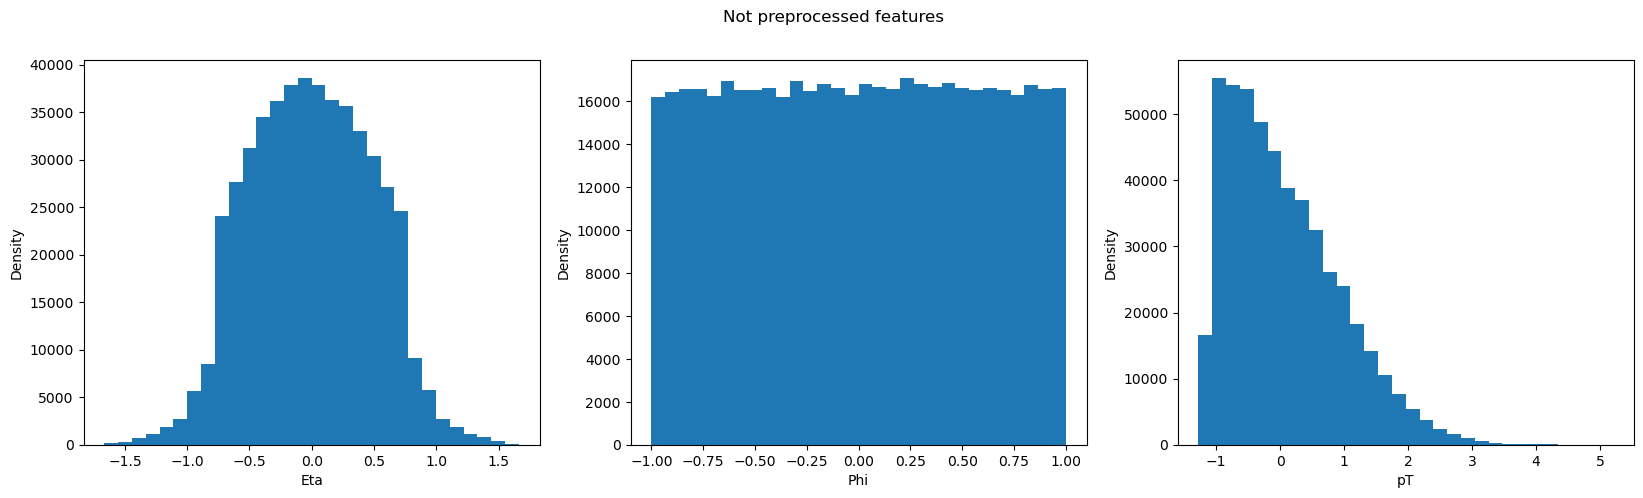

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(20,5))

ax[0].hist(eta, bins=30)
ax[0].set_xlabel("Eta")
ax[0].set_ylabel("Density")

ax[1].hist(phi, bins=30)
ax[1].set_xlabel("Phi")
ax[1].set_ylabel("Density")

ax[2].hist(pT, bins=30)
ax[2].set_xlabel("pT")
ax[2].set_ylabel("Density")

fig.suptitle("Not preprocessed features")
plt.show()

In [6]:
eta, phi, pT = extract_features(dataset_preprocessed)

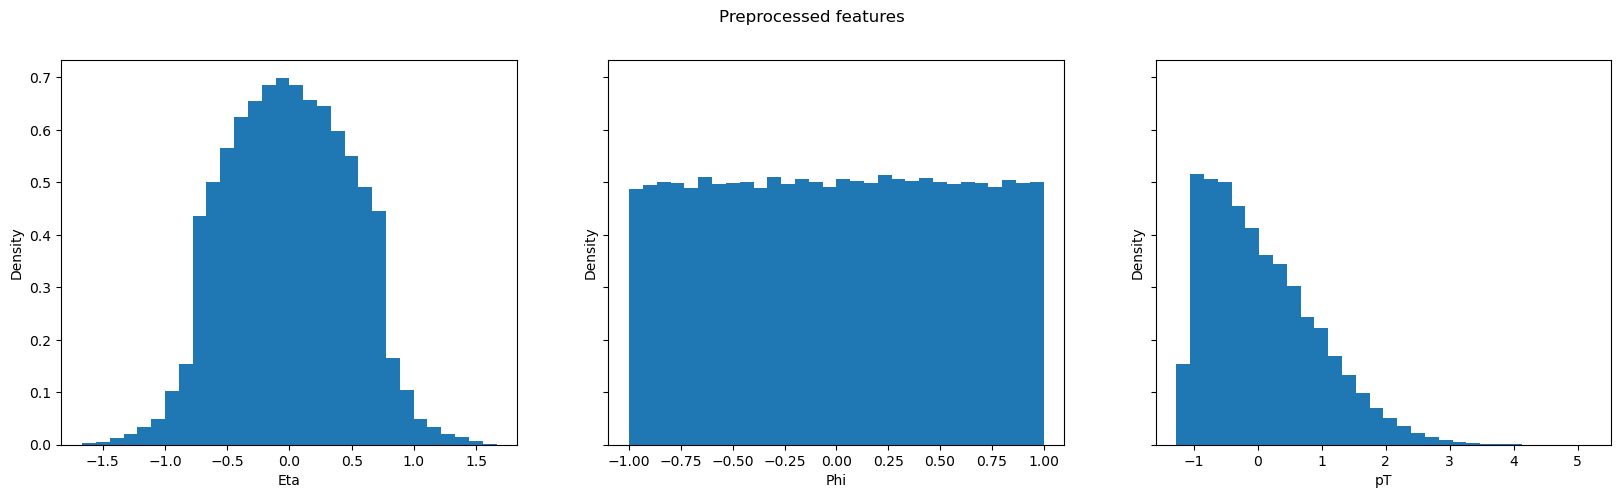

In [12]:
fig, ax = plt.subplots(1, 3, sharey=True, figsize=(20,5))

ax[0].hist(eta, density=True, bins=30)
ax[0].set_xlabel("Eta")
ax[0].set_ylabel("Density")

ax[1].hist(phi, density=True, bins=30)
ax[1].set_xlabel("Phi")
ax[1].set_ylabel("Density")

ax[2].hist(pT, density=True, bins=30)
ax[2].set_xlabel("pT")
ax[2].set_ylabel("Density")


plt.suptitle("Preprocessed features")
plt.show()